# 5. Comparação entre os Cenários A e B

Este notebook compara os resultados obtidos com dois conjuntos de variáveis:

- Cenário A: histórico agregado da trajetória de fluxo;
- Cenário B: histórico agregado + informações desagregadas da taxa de evasão.

Os modelos, protocolos temporais e métricas permanecem iguais entre os cenários.

## 5.1 Configuração

In [1]:
from pathlib import Path
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()

while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "src").is_dir()
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto."
    )

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: /home/sara/Documentos/tcc-evasao-ensino-superior


## 5.2 Carregamento dos resultados

In [3]:
CAMINHO_RESULTADOS_A = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_cenario_a.csv"
)

CAMINHO_RESULTADOS_B = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_cenario_b.csv"
)

resultados_a = pd.read_csv(
    CAMINHO_RESULTADOS_A
)

resultados_b = pd.read_csv(
    CAMINHO_RESULTADOS_B
)

print("Cenário A:", resultados_a.shape)
print("Cenário B:", resultados_b.shape)

Cenário A: (10, 5)
Cenário B: (10, 5)


In [4]:
print("Modelos A:", resultados_a["modelo"].unique())
print("Modelos B:", resultados_b["modelo"].unique())

print("\nProtocolos A:", resultados_a["protocolo"].unique())
print("Protocolos B:", resultados_b["protocolo"].unique())

Modelos A: <StringArray>
[     'Persistência',  'Regressão Linear',             'Ridge',
     'Random Forest', 'Gradient Boosting']
Length: 5, dtype: str
Modelos B: <StringArray>
[     'Persistência',  'Regressão Linear',             'Ridge',
     'Random Forest', 'Gradient Boosting']
Length: 5, dtype: str

Protocolos A: <StringArray>
['Expanding', 'Rolling']
Length: 2, dtype: str
Protocolos B: <StringArray>
['Expanding', 'Rolling']
Length: 2, dtype: str


In [5]:
assert set(
    zip(
        resultados_a["modelo"],
        resultados_a["protocolo"]
    )
) == set(
    zip(
        resultados_b["modelo"],
        resultados_b["protocolo"]
    )
)

print(
    "Os Cenários A e B possuem exatamente as mesmas "
    "combinações de modelo e protocolo."
)

Os Cenários A e B possuem exatamente as mesmas combinações de modelo e protocolo.


## 5.3 Comparação das métricas

In [6]:
comparacao = resultados_a.merge(
    resultados_b,
    on=["modelo", "protocolo"],
    suffixes=("_A", "_B")
)

comparacao

,modelo,protocolo,MAE_A,RMSE_A,R2_A,MAE_B,RMSE_B,R2_B
0,Persistência,Expanding,1.9840,2.5240,-0.2399,1.9840,2.5240,-0.2399
1,Persistência,Rolling,1.9840,2.5240,-0.2399,1.9840,2.5240,-0.2399
2,Regressão Linear,Expanding,1.5891,2.1761,0.0783,1.6713,2.1564,0.0949
3,Regressão Linear,Rolling,1.5988,2.1127,0.1312,1.7276,2.1426,0.1065
4,Ridge,Expanding,1.5823,2.1419,0.1071,1.6553,2.1557,0.0955
5,Ridge,Rolling,1.6214,2.1102,0.1333,1.6732,2.1042,0.1383
6,Random Forest,Expanding,1.7317,2.2991,-0.0288,1.8504,2.3208,-0.0483
7,Random Forest,Rolling,1.7138,2.2549,0.0104,1.8628,2.3174,-0.0452
8,Gradient Boosting,Expanding,1.8782,2.4053,-0.1261,1.7686,2.3054,-0.0345
9,Gradient Boosting,Rolling,1.8422,2.3523,-0.0770,1.7867,2.3035,-0.0327


In [7]:
comparacao["delta_MAE"] = (
    comparacao["MAE_B"]
    - comparacao["MAE_A"]
)

comparacao["delta_RMSE"] = (
    comparacao["RMSE_B"]
    - comparacao["RMSE_A"]
)

comparacao["delta_R2"] = (
    comparacao["R2_B"]
    - comparacao["R2_A"]
)

In [8]:
comparacao["variacao_MAE_%"] = (
    (
        comparacao["MAE_B"]
        - comparacao["MAE_A"]
    )
    / comparacao["MAE_A"]
    * 100
)

comparacao["variacao_RMSE_%"] = (
    (
        comparacao["RMSE_B"]
        - comparacao["RMSE_A"]
    )
    / comparacao["RMSE_A"]
    * 100
)

In [10]:
tabela_comparacao = comparacao[
    [
        "modelo",
        "protocolo",
        "MAE_A",
        "MAE_B",
        "delta_MAE",
        "variacao_MAE_%",
        "RMSE_A",
        "RMSE_B",
        "delta_RMSE",
        "variacao_RMSE_%",
        "R2_A",
        "R2_B",
        "delta_R2"
    ]
].round(4)

tabela_comparacao

,modelo,protocolo,MAE_A,MAE_B,delta_MAE,variacao_MAE_%,RMSE_A,RMSE_B,delta_RMSE,variacao_RMSE_%,R2_A,R2_B,delta_R2
0,Persistência,Expanding,1.9840,1.9840,0.0000,0.0000,2.5240,2.5240,0.0000,0.0000,-0.2399,-0.2399,0.0000
1,Persistência,Rolling,1.9840,1.9840,0.0000,0.0000,2.5240,2.5240,0.0000,0.0000,-0.2399,-0.2399,0.0000
2,Regressão Linear,Expanding,1.5891,1.6713,0.0822,5.1727,2.1761,2.1564,-0.0197,-0.9053,0.0783,0.0949,0.0166
3,Regressão Linear,Rolling,1.5988,1.7276,0.1288,8.0560,2.1127,2.1426,0.0299,1.4153,0.1312,0.1065,-0.0247
4,Ridge,Expanding,1.5823,1.6553,0.0730,4.6135,2.1419,2.1557,0.0138,0.6443,0.1071,0.0955,-0.0116
5,Ridge,Rolling,1.6214,1.6732,0.0518,3.1948,2.1102,2.1042,-0.0060,-0.2843,0.1333,0.1383,0.0050
6,Random Forest,Expanding,1.7317,1.8504,0.1187,6.8545,2.2991,2.3208,0.0217,0.9438,-0.0288,-0.0483,-0.0195
7,Random Forest,Rolling,1.7138,1.8628,0.1490,8.6941,2.2549,2.3174,0.0625,2.7717,0.0104,-0.0452,-0.0556
8,Gradient Boosting,Expanding,1.8782,1.7686,-0.1096,-5.8354,2.4053,2.3054,-0.0999,-4.1533,-0.1261,-0.0345,0.0916
9,Gradient Boosting,Rolling,1.8422,1.7867,-0.0555,-3.0127,2.3523,2.3035,-0.0488,-2.0746,-0.0770,-0.0327,0.0443


In [11]:
tabela_deltas = comparacao[
    [
        "modelo",
        "protocolo",
        "delta_MAE",
        "delta_RMSE",
        "delta_R2"
    ]
].round(4)

tabela_deltas

,modelo,protocolo,delta_MAE,delta_RMSE,delta_R2
0,Persistência,Expanding,0.0000,0.0000,0.0000
1,Persistência,Rolling,0.0000,0.0000,0.0000
2,Regressão Linear,Expanding,0.0822,-0.0197,0.0166
3,Regressão Linear,Rolling,0.1288,0.0299,-0.0247
4,Ridge,Expanding,0.0730,0.0138,-0.0116
5,Ridge,Rolling,0.0518,-0.0060,0.0050
6,Random Forest,Expanding,0.1187,0.0217,-0.0195
7,Random Forest,Rolling,0.1490,0.0625,-0.0556
8,Gradient Boosting,Expanding,-0.1096,-0.0999,0.0916
9,Gradient Boosting,Rolling,-0.0555,-0.0488,0.0443


In [12]:
resumo_modelos = (
    comparacao
    .groupby("modelo")[
        [
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
    .mean()
    .round(4)
)

resumo_modelos

,delta_MAE,delta_RMSE,delta_R2
modelo,,,
Gradient Boosting,-0.0826,-0.0743,0.0680
Persistência,0.0000,0.0000,0.0000
Random Forest,0.1339,0.0421,-0.0376
Regressão Linear,0.1055,0.0051,-0.0041
Ridge,0.0624,0.0039,-0.0033


In [13]:
resumo_protocolos = (
    comparacao
    .groupby("protocolo")[
        [
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
    .mean()
    .round(4)
)

resumo_protocolos

,delta_MAE,delta_RMSE,delta_R2
protocolo,,,
Expanding,0.0329,-0.0168,0.0154
Rolling,0.0548,0.0075,-0.0062


In [14]:
def classificar_efeito(row):
    melhorou_erros = (
        row["delta_MAE"] < 0
        and row["delta_RMSE"] < 0
    )

    melhorou_r2 = row["delta_R2"] > 0

    if melhorou_erros and melhorou_r2:
        return "Melhora nas três métricas"

    if (
        melhorou_erros
        and not melhorou_r2
    ):
        return "Redução de erros, R² menor"

    if (
        not melhorou_erros
        and melhorou_r2
    ):
        return "R² maior, erros maiores"

    return "Piora nas três métricas"

In [15]:
comparacao["efeito_cenario_b"] = (
    comparacao.apply(
        classificar_efeito,
        axis=1
    )
)

In [16]:
comparacao[
    [
        "modelo",
        "protocolo",
        "efeito_cenario_b"
    ]
]

,modelo,protocolo,efeito_cenario_b
0,Persistência,Expanding,Piora nas três métricas
1,Persistência,Rolling,Piora nas três métricas
2,Regressão Linear,Expanding,"R² maior, erros maiores"
3,Regressão Linear,Rolling,Piora nas três métricas
4,Ridge,Expanding,Piora nas três métricas
5,Ridge,Rolling,"R² maior, erros maiores"
6,Random Forest,Expanding,Piora nas três métricas
7,Random Forest,Rolling,Piora nas três métricas
8,Gradient Boosting,Expanding,Melhora nas três métricas
9,Gradient Boosting,Rolling,Melhora nas três métricas


## 5.4 Interpretação do efeito das features adicionais

A comparação entre os Cenários A e B avalia se a inclusão de informações
desagregadas da taxa de evasão no período anterior modifica o desempenho
preditivo dos modelos.

Os mesmos modelos, protocolos temporais, períodos de teste e métricas foram
mantidos nos dois cenários. Assim, a principal diferença experimental entre
A e B é o conjunto de variáveis preditoras.

## 5.5 Efeito do Cenário B por período

In [29]:
CAMINHO_FOLDS_A = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_por_fold_cenario_a.csv"
)

CAMINHO_FOLDS_B = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resultados_por_fold_cenario_b.csv"
)

folds_a = pd.read_csv(
    CAMINHO_FOLDS_A
)

folds_b = pd.read_csv(
    CAMINHO_FOLDS_B
)

print("Cenário A:", folds_a.shape)
print("Cenário B:", folds_b.shape)

Cenário A: (30, 9)
Cenário B: (30, 9)


In [30]:
gb_a = folds_a[
    folds_a["modelo"] == "Gradient Boosting"
].copy()

gb_b = folds_b[
    folds_b["modelo"] == "Gradient Boosting"
].copy()

In [31]:
comparacao_gb_folds = gb_a.merge(
    gb_b,
    on=[
        "modelo",
        "protocolo",
        "fold",
        "periodo_teste"
    ],
    suffixes=("_A", "_B")
)

In [32]:
comparacao_gb_folds["delta_MAE"] = (
    comparacao_gb_folds["mae_B"]
    - comparacao_gb_folds["mae_A"]
)

comparacao_gb_folds["delta_RMSE"] = (
    comparacao_gb_folds["rmse_B"]
    - comparacao_gb_folds["rmse_A"]
)

comparacao_gb_folds["delta_R2"] = (
    comparacao_gb_folds["r2_B"]
    - comparacao_gb_folds["r2_A"]
)

In [33]:
comparacao_gb_folds[
    [
        "protocolo",
        "fold",
        "periodo_teste",
        "mae_A",
        "mae_B",
        "delta_MAE",
        "rmse_A",
        "rmse_B",
        "delta_RMSE",
        "r2_A",
        "r2_B",
        "delta_R2"
    ]
].round(4)

,protocolo,fold,periodo_teste,mae_A,mae_B,delta_MAE,rmse_A,rmse_B,delta_RMSE,r2_A,r2_B,delta_R2
0,Expanding,1,2021,2.2127,2.3531,0.1404,2.6563,2.7616,0.1052,-0.3612,-0.4711,-0.1100
1,Rolling,1,2021,2.2127,2.3531,0.1404,2.6563,2.7616,0.1052,-0.3612,-0.4711,-0.1100
2,Expanding,2,2022,1.7493,1.2819,-0.4674,2.3838,2.0240,-0.3597,-0.1722,0.1549,0.3271
3,Rolling,2,2022,1.6385,1.3095,-0.3291,2.2702,1.9824,-0.2878,-0.0631,0.1893,0.2524
4,Expanding,3,2023,1.6728,1.6708,-0.0020,2.1490,2.0548,-0.0942,-0.0383,0.0508,0.0890
5,Rolling,3,2023,1.6753,1.6974,0.0221,2.0952,2.0884,-0.0067,0.0131,0.0194,0.0063


In [34]:
comparacao_gb_folds["melhora_MAE"] = (
    comparacao_gb_folds["delta_MAE"] < 0
)

comparacao_gb_folds["melhora_RMSE"] = (
    comparacao_gb_folds["delta_RMSE"] < 0
)

comparacao_gb_folds["melhora_R2"] = (
    comparacao_gb_folds["delta_R2"] > 0
)

In [35]:
comparacao_gb_folds[
    [
        "protocolo",
        "periodo_teste",
        "melhora_MAE",
        "melhora_RMSE",
        "melhora_R2"
    ]
]

,protocolo,periodo_teste,melhora_MAE,melhora_RMSE,melhora_R2
0,Expanding,2021,False,False,False
1,Rolling,2021,False,False,False
2,Expanding,2022,True,True,True
3,Rolling,2022,True,True,True
4,Expanding,2023,True,True,True
5,Rolling,2023,False,True,True


In [36]:
comparacao_gb_folds[
    [
        "protocolo",
        "periodo_teste",
        "delta_MAE",
        "delta_RMSE",
        "delta_R2"
    ]
].sort_values(
    ["protocolo", "periodo_teste"]
).round(4)

,protocolo,periodo_teste,delta_MAE,delta_RMSE,delta_R2
0,Expanding,2021,0.1404,0.1052,-0.1100
2,Expanding,2022,-0.4674,-0.3597,0.3271
4,Expanding,2023,-0.0020,-0.0942,0.0890
1,Rolling,2021,0.1404,0.1052,-0.1100
3,Rolling,2022,-0.3291,-0.2878,0.2524
5,Rolling,2023,0.0221,-0.0067,0.0063


In [37]:
comparacao_folds = folds_a.merge(
    folds_b,
    on=[
        "modelo",
        "protocolo",
        "fold",
        "periodo_teste"
    ],
    suffixes=("_A", "_B")
)

comparacao_folds["delta_MAE"] = (
    comparacao_folds["mae_B"]
    - comparacao_folds["mae_A"]
)

comparacao_folds["delta_RMSE"] = (
    comparacao_folds["rmse_B"]
    - comparacao_folds["rmse_A"]
)

comparacao_folds["delta_R2"] = (
    comparacao_folds["r2_B"]
    - comparacao_folds["r2_A"]
)

In [38]:
(
    comparacao_folds
    .pivot_table(
        index="periodo_teste",
        columns=["modelo", "protocolo"],
        values="delta_MAE"
    )
    .round(4)
)

modelo        Gradient Boosting         Persistência         Random Forest  \
protocolo             Expanding Rolling    Expanding Rolling     Expanding   
periodo_teste                                                                
2021                     0.1404  0.1404          0.0     0.0        0.0771   
2022                    -0.4674 -0.3291          0.0     0.0        0.1192   
2023                    -0.0020  0.0221          0.0     0.0        0.1600   

modelo                Regressão Linear             Ridge          
protocolo     Rolling        Expanding Rolling Expanding Rolling  
periodo_teste                                                     
2021           0.0771           0.0073  0.0073    0.0707  0.0707  
2022           0.1676           0.4563  0.4518    0.4073  0.1636  
2023           0.2022          -0.2172 -0.0727   -0.2591 -0.0787

In [39]:
resumo_efeito_b = (
    comparacao_folds
    .groupby(["modelo", "protocolo"])[
        [
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
    .agg(
        media_MAE=("delta_MAE", "mean"),
        media_RMSE=("delta_RMSE", "mean"),
        media_R2=("delta_R2", "mean"),
        folds_MAE_melhor=("delta_MAE", lambda x: (x < 0).sum()),
        folds_RMSE_melhor=("delta_RMSE", lambda x: (x < 0).sum()),
        folds_R2_melhor=("delta_R2", lambda x: (x > 0).sum())
    )
    .round(4)
    .reset_index()
)

resumo_efeito_b

,modelo,protocolo,media_MAE,media_RMSE,media_R2,folds_MAE_melhor,folds_RMSE_melhor,folds_R2_melhor
0,Gradient Boosting,Expanding,-0.1096,-0.1162,0.1021,2,2,2
1,Gradient Boosting,Rolling,-0.0555,-0.0631,0.0496,1,2,2
2,Persistência,Expanding,0.0000,0.0000,0.0000,0,0,0
3,Persistência,Rolling,0.0000,0.0000,0.0000,0,0,0
4,Random Forest,Expanding,0.1187,0.0235,-0.0212,0,1,1
5,Random Forest,Rolling,0.1489,0.0701,-0.0638,0,1,1
6,Regressão Linear,Expanding,0.0821,-0.0459,0.0218,1,2,2
7,Regressão Linear,Rolling,0.1288,0.0213,-0.0246,1,2,2
8,Ridge,Expanding,0.0730,-0.0074,-0.0064,1,2,2
9,Ridge,Rolling,0.0519,-0.0098,0.0082,1,2,2


## 5.6 Efeito do Cenário B por período de teste

In [40]:
comparacao_por_periodo = (
    comparacao_folds[
        [
            "modelo",
            "protocolo",
            "periodo_teste",
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
    .sort_values(
        ["protocolo", "periodo_teste", "modelo"]
    )
    .reset_index(drop=True)
)

comparacao_por_periodo.round(4)

,modelo,protocolo,periodo_teste,delta_MAE,delta_RMSE,delta_R2
0,Gradient Boosting,Expanding,2021,0.1404,0.1052,-0.1100
1,Persistência,Expanding,2021,0.0000,0.0000,0.0000
2,Random Forest,Expanding,2021,0.0771,-0.0218,0.0218
3,Regressão Linear,Expanding,2021,0.0073,-0.1487,0.1369
4,Ridge,Expanding,2021,0.0707,-0.0585,0.0545
5,Gradient Boosting,Expanding,2022,-0.4674,-0.3597,0.3271
6,Persistência,Expanding,2022,0.0000,0.0000,0.0000
7,Random Forest,Expanding,2022,0.1192,0.0893,-0.0828
8,Regressão Linear,Expanding,2022,0.4563,0.3565,-0.3397
9,Ridge,Expanding,2022,0.4073,0.3644,-0.3323


In [41]:
tabela_delta_mae_periodo = (
    comparacao_folds
    .pivot_table(
        index="periodo_teste",
        columns=["modelo", "protocolo"],
        values="delta_MAE"
    )
    .round(4)
)

tabela_delta_mae_periodo

modelo        Gradient Boosting         Persistência         Random Forest  \
protocolo             Expanding Rolling    Expanding Rolling     Expanding   
periodo_teste                                                                
2021                     0.1404  0.1404          0.0     0.0        0.0771   
2022                    -0.4674 -0.3291          0.0     0.0        0.1192   
2023                    -0.0020  0.0221          0.0     0.0        0.1600   

modelo                Regressão Linear             Ridge          
protocolo     Rolling        Expanding Rolling Expanding Rolling  
periodo_teste                                                     
2021           0.0771           0.0073  0.0073    0.0707  0.0707  
2022           0.1676           0.4563  0.4518    0.4073  0.1636  
2023           0.2022          -0.2172 -0.0727   -0.2591 -0.0787

In [42]:
gb_temporal = (
    comparacao_folds[
        comparacao_folds["modelo"] == "Gradient Boosting"
    ][
        [
            "protocolo",
            "periodo_teste",
            "mae_A",
            "mae_B",
            "delta_MAE",
            "rmse_A",
            "rmse_B",
            "delta_RMSE",
            "r2_A",
            "r2_B",
            "delta_R2"
        ]
    ]
    .sort_values(
        ["protocolo", "periodo_teste"]
    )
)

gb_temporal.round(4)

,protocolo,periodo_teste,mae_A,mae_B,delta_MAE,rmse_A,rmse_B,delta_RMSE,r2_A,r2_B,delta_R2
0,Expanding,2021,2.2127,2.3531,0.1404,2.6563,2.7616,0.1052,-0.3612,-0.4711,-0.1100
10,Expanding,2022,1.7493,1.2819,-0.4674,2.3838,2.0240,-0.3597,-0.1722,0.1549,0.3271
20,Expanding,2023,1.6728,1.6708,-0.0020,2.1490,2.0548,-0.0942,-0.0383,0.0508,0.0890
5,Rolling,2021,2.2127,2.3531,0.1404,2.6563,2.7616,0.1052,-0.3612,-0.4711,-0.1100
15,Rolling,2022,1.6385,1.3095,-0.3291,2.2702,1.9824,-0.2878,-0.0631,0.1893,0.2524
25,Rolling,2023,1.6753,1.6974,0.0221,2.0952,2.0884,-0.0067,0.0131,0.0194,0.0063


In [43]:
frequencia_melhoria = (
    comparacao_folds
    .groupby(["modelo", "protocolo"])
    .agg(
        folds_mae_melhor=(
            "delta_MAE",
            lambda x: (x < 0).sum()
        ),
        folds_rmse_melhor=(
            "delta_RMSE",
            lambda x: (x < 0).sum()
        ),
        folds_r2_melhor=(
            "delta_R2",
            lambda x: (x > 0).sum()
        ),
        total_folds=(
            "delta_MAE",
            "count"
        )
    )
    .reset_index()
)

frequencia_melhoria

,modelo,protocolo,folds_mae_melhor,folds_rmse_melhor,folds_r2_melhor,total_folds
0,Gradient Boosting,Expanding,2,2,2,3
1,Gradient Boosting,Rolling,1,2,2,3
2,Persistência,Expanding,0,0,0,3
3,Persistência,Rolling,0,0,0,3
4,Random Forest,Expanding,0,1,1,3
5,Random Forest,Rolling,0,1,1,3
6,Regressão Linear,Expanding,1,2,2,3
7,Regressão Linear,Rolling,1,2,2,3
8,Ridge,Expanding,1,2,2,3
9,Ridge,Rolling,1,2,2,3


In [44]:
def classificar_delta_mae(delta):
    if delta < 0:
        return "Redução do MAE"
    elif delta > 0:
        return "Aumento do MAE"
    return "Sem alteração"

In [45]:
comparacao_por_periodo["efeito_MAE"] = (
    comparacao_por_periodo["delta_MAE"]
    .apply(classificar_delta_mae)
)

In [46]:
comparacao_por_periodo[
    [
        "modelo",
        "protocolo",
        "periodo_teste",
        "delta_MAE",
        "efeito_MAE"
    ]
]

,modelo,protocolo,periodo_teste,delta_MAE,efeito_MAE
0,Gradient Boosting,Expanding,2021,0.140406,Aumento do MAE
1,Persistência,Expanding,2021,0.000000,Sem alteração
2,Random Forest,Expanding,2021,0.077067,Aumento do MAE
3,Regressão Linear,Expanding,2021,0.007346,Aumento do MAE
4,Ridge,Expanding,2021,0.070686,Aumento do MAE
5,Gradient Boosting,Expanding,2022,-0.467359,Redução do MAE
6,Persistência,Expanding,2022,0.000000,Sem alteração
7,Random Forest,Expanding,2022,0.119165,Aumento do MAE
8,Regressão Linear,Expanding,2022,0.456280,Aumento do MAE
9,Ridge,Expanding,2022,0.407285,Aumento do MAE


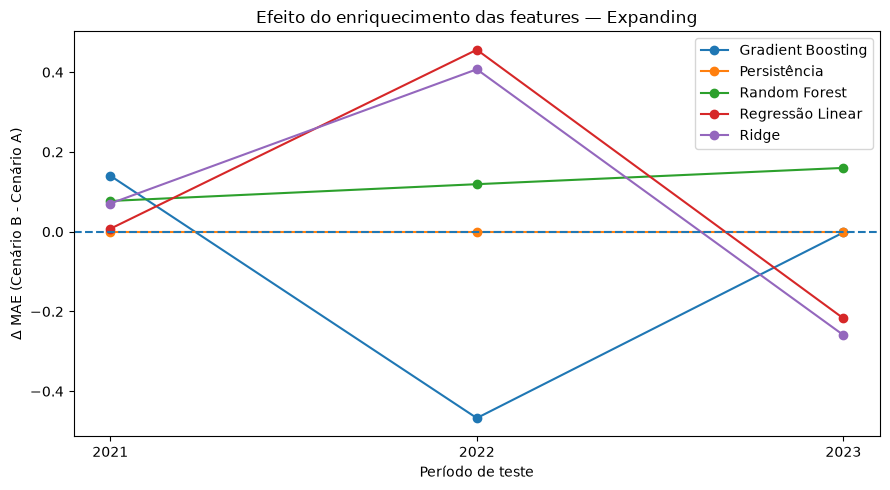

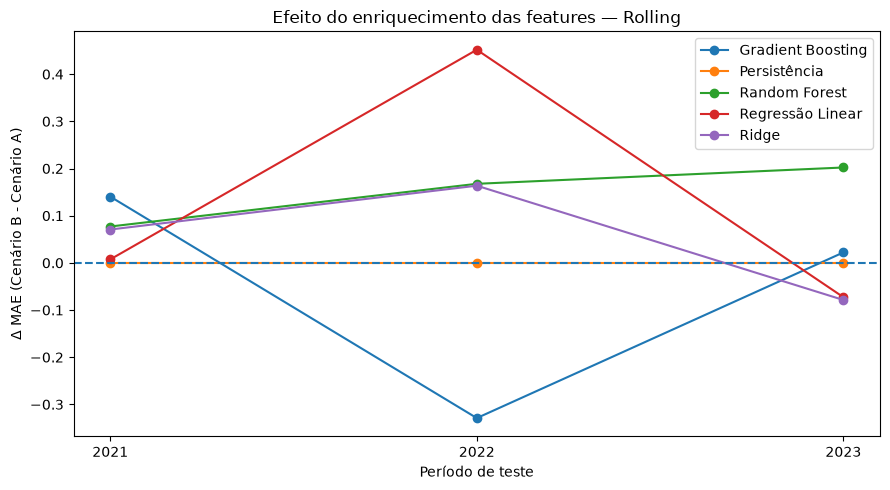

In [47]:
import matplotlib.pyplot as plt

for protocolo in ["Expanding", "Rolling"]:

    dados = comparacao_folds[
        comparacao_folds["protocolo"] == protocolo
    ]

    plt.figure(figsize=(9, 5))

    for modelo in dados["modelo"].unique():

        dados_modelo = dados[
            dados["modelo"] == modelo
        ].sort_values("periodo_teste")

        plt.plot(
            dados_modelo["periodo_teste"].astype(str),
            dados_modelo["delta_MAE"],
            marker="o",
            label=modelo
        )

    plt.axhline(0, linestyle="--")

    plt.xlabel("Período de teste")
    plt.ylabel("Δ MAE (Cenário B - Cenário A)")
    plt.title(
        f"Efeito do enriquecimento das features — {protocolo}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

A inclusão das variáveis desagregadas reduziu o MAE médio do Gradient Boosting nos dois protocolos, mas esse ganho foi concentrado principalmente no período de teste 2022–2023; nos demais períodos, o efeito foi pequeno ou desfavorável.

## 5.7 Exportação das comparações entre cenários

In [48]:
CAMINHO_COMPARACAO_CENARIOS = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "comparacao_cenarios_detalhada.csv"
)

comparacao_por_periodo.to_csv(
    CAMINHO_COMPARACAO_CENARIOS,
    index=False
)

In [49]:
CAMINHO_RESUMO_EFEITO = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resumo_efeito_cenario_b.csv"
)

resumo_efeito_b.to_csv(
    CAMINHO_RESUMO_EFEITO,
    index=False
)

## 5.7 Relação entre efeito do Cenário B e importância das features

In [50]:
CAMINHO_IMPORTANCIAS_GB = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "importancias_gb_cenario_b_expanding.csv"
)

importancias_gb = pd.read_csv(
    CAMINHO_IMPORTANCIAS_GB
)

print(importancias_gb.shape)

(51, 6)


In [51]:
features_principais_gb = [
    "evasao_feminino_t_1",
    "evasao_20_22_t_1",
    "evasao_ate_19_t_1",
    "evasao_ppi_nao_t_1",
    "permanencia_t_1"
]

In [52]:
importancias_principais = (
    importancias_gb[
        importancias_gb["feature"].isin(
            features_principais_gb
        )
    ][
        [
            "feature",
            "importance_mean",
            "importance_std",
            "fold",
            "periodo_teste"
        ]
    ]
    .sort_values(
        ["periodo_teste", "importance_mean"],
        ascending=[True, False]
    )
)

importancias_principais.round(4)

,feature,importance_mean,importance_std,fold,periodo_teste
9,evasao_20_22_t_1,0.1841,0.1402,1,2021
4,evasao_feminino_t_1,0.1152,0.0746,1,2021
8,evasao_ate_19_t_1,0.0197,0.0100,1,2021
7,evasao_ppi_nao_t_1,0.0177,0.0146,1,2021
3,permanencia_t_1,-0.0755,0.0444,1,2021
21,evasao_feminino_t_1,0.1443,0.0576,2,2022
26,evasao_20_22_t_1,0.1380,0.0850,2,2022
25,evasao_ate_19_t_1,0.1168,0.0722,2,2022
24,evasao_ppi_nao_t_1,0.0739,0.0712,2,2022
20,permanencia_t_1,0.0425,0.0219,2,2022


In [53]:
gb_expanding_efeito = (
    comparacao_gb_folds[
        comparacao_gb_folds["protocolo"] == "Expanding"
    ][
        [
            "periodo_teste",
            "delta_MAE",
            "delta_RMSE",
            "delta_R2"
        ]
    ]
)

In [54]:
importancias_largo = (
    importancias_principais
    .pivot(
        index="periodo_teste",
        columns="feature",
        values="importance_mean"
    )
    .reset_index()
)

In [55]:
gb_efeito_importancias = gb_expanding_efeito.merge(
    importancias_largo,
    on="periodo_teste",
    how="left"
)

gb_efeito_importancias.round(4)

,periodo_teste,delta_MAE,delta_RMSE,delta_R2,evasao_20_22_t_1,evasao_ate_19_t_1,evasao_feminino_t_1,evasao_ppi_nao_t_1,permanencia_t_1
0,2021,0.1404,0.1052,-0.1100,0.1841,0.0197,0.1152,0.0177,-0.0755
1,2022,-0.4674,-0.3597,0.3271,0.1380,0.1168,0.1443,0.0739,0.0425
2,2023,-0.0020,-0.0942,0.0890,-0.0003,0.0364,0.1708,-0.0021,0.1133


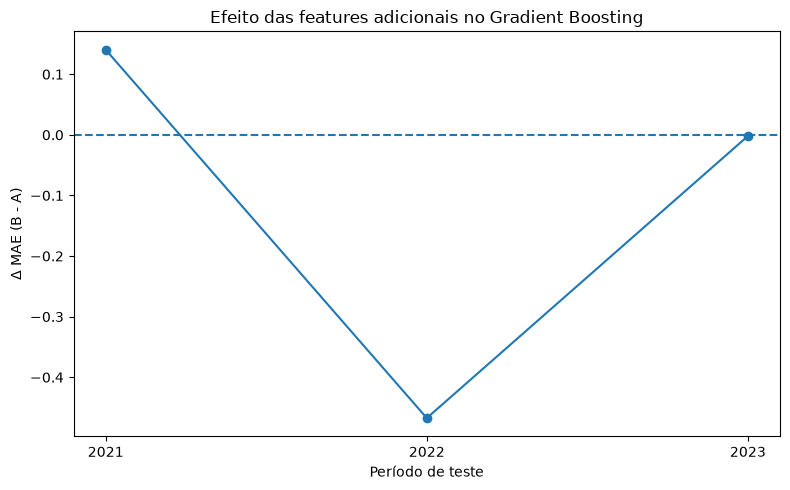

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    gb_efeito_importancias["periodo_teste"].astype(str),
    gb_efeito_importancias["delta_MAE"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Período de teste")
plt.ylabel("Δ MAE (B - A)")
plt.title(
    "Efeito das features adicionais no Gradient Boosting"
)

plt.tight_layout()
plt.show()

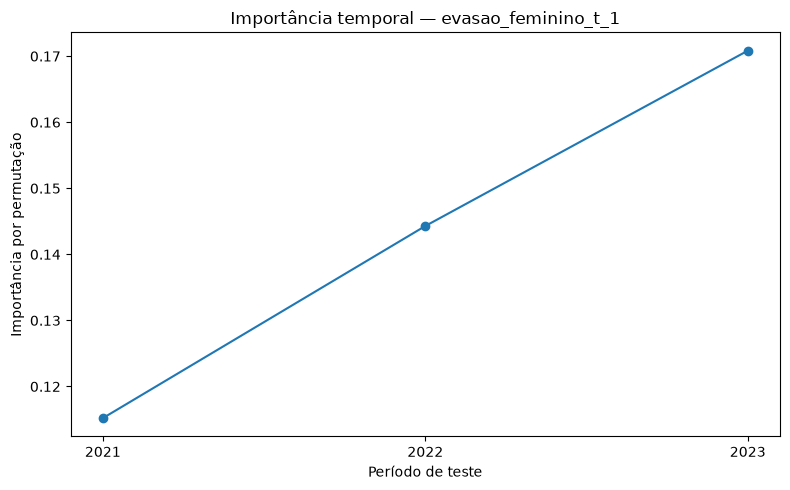

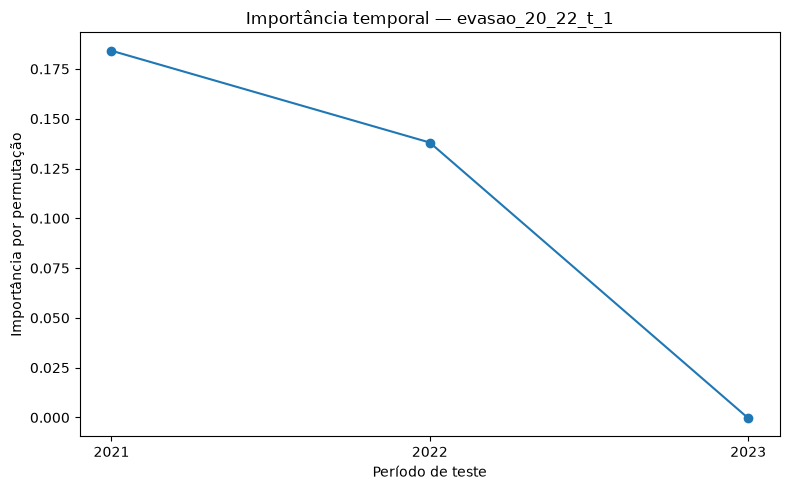

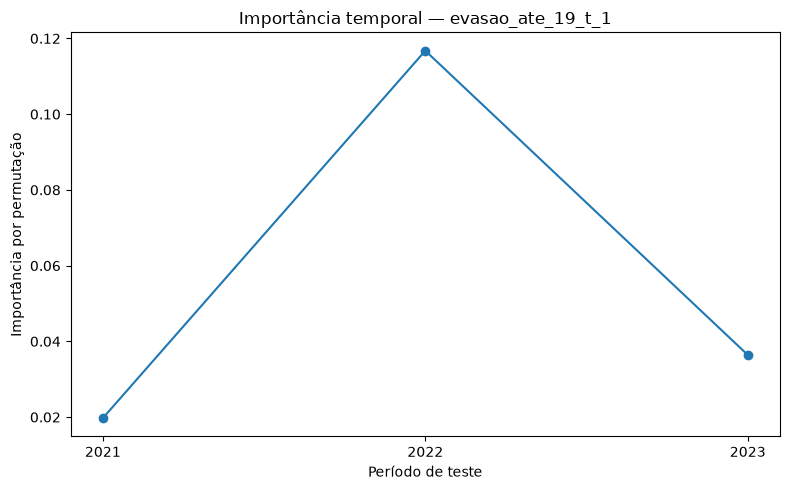

In [57]:
features_plot = [
    "evasao_feminino_t_1",
    "evasao_20_22_t_1",
    "evasao_ate_19_t_1"
]

for feature in features_plot:

    plt.figure(figsize=(8, 5))

    dados = importancias_principais[
        importancias_principais["feature"] == feature
    ].sort_values("periodo_teste")

    plt.plot(
        dados["periodo_teste"].astype(str),
        dados["importance_mean"],
        marker="o"
    )

    plt.xlabel("Período de teste")
    plt.ylabel("Importância por permutação")
    plt.title(
        f"Importância temporal — {feature}"
    )

    plt.tight_layout()
    plt.show()

In [58]:
resumo_gb_temporal = gb_efeito_importancias[
    [
        "periodo_teste",
        "delta_MAE",
        "delta_RMSE",
        "delta_R2",
        "evasao_feminino_t_1",
        "evasao_20_22_t_1",
        "evasao_ate_19_t_1",
        "evasao_ppi_nao_t_1",
        "permanencia_t_1"
    ]
].round(4)

resumo_gb_temporal

,periodo_teste,delta_MAE,delta_RMSE,delta_R2,evasao_feminino_t_1,evasao_20_22_t_1,evasao_ate_19_t_1,evasao_ppi_nao_t_1,permanencia_t_1
0,2021,0.1404,0.1052,-0.1100,0.1152,0.1841,0.0197,0.0177,-0.0755
1,2022,-0.4674,-0.3597,0.3271,0.1443,0.1380,0.1168,0.0739,0.0425
2,2023,-0.0020,-0.0942,0.0890,0.1708,-0.0003,0.0364,-0.0021,0.1133


In [59]:
CAMINHO_RESUMO_GB = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resumo_gb_efeito_importancias.csv"
)

resumo_gb_temporal.to_csv(
    CAMINHO_RESUMO_GB,
    index=False
)

O efeito das informações desagregadas variou entre os períodos de teste. O maior ganho do Gradient Boosting ocorreu em 2022–2023, período no qual diversas variáveis desagregadas apresentaram importância preditiva relevante. Entretanto, a variação temporal das importâncias não acompanha de forma unívoca a variação do desempenho, sugerindo que o ganho decorre da combinação das informações utilizadas pelo modelo, e não de uma única variável isolada.

In [60]:
gb_a = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "tables"
    / "previsoes_gb_cenario_a_expanding.csv"
)

gb_b = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "tables"
    / "previsoes_gb_cenario_b_expanding.csv"
)

print("Cenário A:", gb_a.shape)
print("Cenário B:", gb_b.shape)

Cenário A: (81, 7)
Cenário B: (81, 7)


In [61]:
gb_a = gb_a[
    ["uf", "ano_fluxo", "evasao_t", "previsao"]
].rename(
    columns={"previsao": "previsao_A"}
)

gb_b = gb_b[
    ["uf", "ano_fluxo", "previsao"]
].rename(
    columns={"previsao": "previsao_B"}
)

gb_ab = gb_a.merge(
    gb_b,
    on=["uf", "ano_fluxo"],
    how="inner"
)

print("Observações:", len(gb_ab))
print("UFs:", gb_ab["uf"].nunique())
print("Períodos:", gb_ab["ano_fluxo"].nunique())

Observações: 81
UFs: 27
Períodos: 3


In [62]:
gb_ab["erro_A"] = (
    gb_ab["evasao_t"]
    - gb_ab["previsao_A"]
)

gb_ab["erro_B"] = (
    gb_ab["evasao_t"]
    - gb_ab["previsao_B"]
)

gb_ab["erro_abs_A"] = (
    gb_ab["erro_A"].abs()
)

gb_ab["erro_abs_B"] = (
    gb_ab["erro_B"].abs()
)

gb_ab["delta_erro_abs"] = (
    gb_ab["erro_abs_B"]
    - gb_ab["erro_abs_A"]
)

In [63]:
gb_2022 = (
    gb_ab[
        gb_ab["ano_fluxo"] == "2022-2023"
    ]
    .sort_values("delta_erro_abs")
)

gb_2022[
    [
        "uf",
        "evasao_t",
        "previsao_A",
        "previsao_B",
        "erro_abs_A",
        "erro_abs_B",
        "delta_erro_abs"
    ]
].round(3)

,uf,evasao_t,previsao_A,previsao_B,erro_abs_A,erro_abs_B,delta_erro_abs
38,Mato Grosso do Sul,17.2,15.263,17.196,1.937,0.004,-1.932
42,Pará,17.6,15.669,17.367,1.931,0.233,-1.698
35,Goiás,17.1,15.318,17.196,1.782,0.096,-1.686
47,Rio de Janeiro,14.1,15.835,14.155,1.735,0.055,-1.680
29,Amapá,18.5,16.382,17.974,2.118,0.526,-1.592
37,Mato Grosso,17.9,15.669,17.110,2.231,0.790,-1.441
33,Distrito Federal,14.7,16.608,13.868,1.908,0.832,-1.076
53,Tocantins,17.3,13.310,14.087,3.990,3.213,-0.777
39,Minas Gerais,14.5,15.407,14.328,0.907,0.172,-0.735
31,Bahia,17.3,15.669,16.399,1.631,0.901,-0.730


In [64]:
melhoraram = (
    gb_2022["delta_erro_abs"] < 0
).sum()

pioraram = (
    gb_2022["delta_erro_abs"] > 0
).sum()

sem_alteracao = (
    gb_2022["delta_erro_abs"] == 0
).sum()

print("Melhoraram:", melhoraram)
print("Pioraram:", pioraram)
print("Sem alteração:", sem_alteracao)

Melhoraram: 21
Pioraram: 6
Sem alteração: 0


In [65]:
gb_2022["delta_erro_abs"].describe().round(3)

count    27.000
mean     -0.467
std       0.928
min      -1.932
25%      -0.926
50%      -0.506
75%      -0.125
max       2.249
Name: delta_erro_abs, dtype: float64

In [66]:
gb_2022[
    [
        "uf",
        "delta_erro_abs"
    ]
].sort_values(
    "delta_erro_abs"
).round(3)

,uf,delta_erro_abs
38,Mato Grosso do Sul,-1.932
42,Pará,-1.698
35,Goiás,-1.686
47,Rio de Janeiro,-1.680
29,Amapá,-1.592
37,Mato Grosso,-1.441
33,Distrito Federal,-1.076
53,Tocantins,-0.777
39,Minas Gerais,-0.735
31,Bahia,-0.730


In [67]:
efeito_uf_periodo = (
    gb_ab
    .groupby("ano_fluxo")
    .agg(
        erro_abs_A_medio=(
            "erro_abs_A",
            "mean"
        ),
        erro_abs_B_medio=(
            "erro_abs_B",
            "mean"
        ),
        delta_medio=(
            "delta_erro_abs",
            "mean"
        ),
        ufs_melhoraram=(
            "delta_erro_abs",
            lambda x: (x < 0).sum()
        ),
        ufs_pioraram=(
            "delta_erro_abs",
            lambda x: (x > 0).sum()
        )
    )
    .round(4)
)

efeito_uf_periodo

,erro_abs_A_medio,erro_abs_B_medio,delta_medio,ufs_melhoraram,ufs_pioraram
ano_fluxo,,,,,
2021-2022,2.2127,2.3531,0.1404,11,16
2022-2023,1.7493,1.2819,-0.4674,21,6
2023-2024,1.6728,1.6708,-0.0020,13,14


O benefício das variáveis adicionais depende do período de teste. Em particular, o Cenário B apresentou ganho expressivo e distribuído entre as UFs em 2022–2023, enquanto apresentou efeito desfavorável em 2021–2022 e praticamente neutro em 2023–2024.

## 5.9 Tabela-síntese do experimento

In [68]:
tabela_final_experimento = (
    comparacao
    .merge(
        frequencia_melhoria[
            [
                "modelo",
                "protocolo",
                "folds_mae_melhor",
                "folds_rmse_melhor",
                "folds_r2_melhor",
                "total_folds"
            ]
        ],
        on=["modelo", "protocolo"],
        how="left"
    )
)

In [70]:
tabela_final_experimento = tabela_final_experimento[
    [
        "modelo",
        "protocolo",

        "MAE_A",
        "MAE_B",
        "delta_MAE",

        "RMSE_A",
        "RMSE_B",
        "delta_RMSE",

        "R2_A",
        "R2_B",
        "delta_R2",

        "folds_mae_melhor",
        "folds_rmse_melhor",
        "folds_r2_melhor",
        "total_folds"
    ]
].round(4)

tabela_final_experimento

,modelo,protocolo,MAE_A,MAE_B,delta_MAE,RMSE_A,RMSE_B,delta_RMSE,R2_A,R2_B,delta_R2,folds_mae_melhor,folds_rmse_melhor,folds_r2_melhor,total_folds
0,Persistência,Expanding,1.9840,1.9840,0.0000,2.5240,2.5240,0.0000,-0.2399,-0.2399,0.0000,0,0,0,3
1,Persistência,Rolling,1.9840,1.9840,0.0000,2.5240,2.5240,0.0000,-0.2399,-0.2399,0.0000,0,0,0,3
2,Regressão Linear,Expanding,1.5891,1.6713,0.0822,2.1761,2.1564,-0.0197,0.0783,0.0949,0.0166,1,2,2,3
3,Regressão Linear,Rolling,1.5988,1.7276,0.1288,2.1127,2.1426,0.0299,0.1312,0.1065,-0.0247,1,2,2,3
4,Ridge,Expanding,1.5823,1.6553,0.0730,2.1419,2.1557,0.0138,0.1071,0.0955,-0.0116,1,2,2,3
5,Ridge,Rolling,1.6214,1.6732,0.0518,2.1102,2.1042,-0.0060,0.1333,0.1383,0.0050,1,2,2,3
6,Random Forest,Expanding,1.7317,1.8504,0.1187,2.2991,2.3208,0.0217,-0.0288,-0.0483,-0.0195,0,1,1,3
7,Random Forest,Rolling,1.7138,1.8628,0.1490,2.2549,2.3174,0.0625,0.0104,-0.0452,-0.0556,0,1,1,3
8,Gradient Boosting,Expanding,1.8782,1.7686,-0.1096,2.4053,2.3054,-0.0999,-0.1261,-0.0345,0.0916,2,2,2,3
9,Gradient Boosting,Rolling,1.8422,1.7867,-0.0555,2.3523,2.3035,-0.0488,-0.0770,-0.0327,0.0443,1,2,2,3


In [71]:
tabela_final_resumida = tabela_final_experimento[
    [
        "modelo",
        "protocolo",

        "MAE_A",
        "MAE_B",
        "delta_MAE",

        "RMSE_A",
        "RMSE_B",
        "delta_RMSE",

        "R2_A",
        "R2_B",
        "delta_R2"
    ]
].copy()

tabela_final_resumida

,modelo,protocolo,MAE_A,MAE_B,delta_MAE,RMSE_A,RMSE_B,delta_RMSE,R2_A,R2_B,delta_R2
0,Persistência,Expanding,1.9840,1.9840,0.0000,2.5240,2.5240,0.0000,-0.2399,-0.2399,0.0000
1,Persistência,Rolling,1.9840,1.9840,0.0000,2.5240,2.5240,0.0000,-0.2399,-0.2399,0.0000
2,Regressão Linear,Expanding,1.5891,1.6713,0.0822,2.1761,2.1564,-0.0197,0.0783,0.0949,0.0166
3,Regressão Linear,Rolling,1.5988,1.7276,0.1288,2.1127,2.1426,0.0299,0.1312,0.1065,-0.0247
4,Ridge,Expanding,1.5823,1.6553,0.0730,2.1419,2.1557,0.0138,0.1071,0.0955,-0.0116
5,Ridge,Rolling,1.6214,1.6732,0.0518,2.1102,2.1042,-0.0060,0.1333,0.1383,0.0050
6,Random Forest,Expanding,1.7317,1.8504,0.1187,2.2991,2.3208,0.0217,-0.0288,-0.0483,-0.0195
7,Random Forest,Rolling,1.7138,1.8628,0.1490,2.2549,2.3174,0.0625,0.0104,-0.0452,-0.0556
8,Gradient Boosting,Expanding,1.8782,1.7686,-0.1096,2.4053,2.3054,-0.0999,-0.1261,-0.0345,0.0916
9,Gradient Boosting,Rolling,1.8422,1.7867,-0.0555,2.3523,2.3035,-0.0488,-0.0770,-0.0327,0.0443


In [72]:
tabela_consistencia = tabela_final_experimento[
    [
        "modelo",
        "protocolo",
        "folds_mae_melhor",
        "folds_rmse_melhor",
        "folds_r2_melhor",
        "total_folds"
    ]
].copy()

tabela_consistencia

,modelo,protocolo,folds_mae_melhor,folds_rmse_melhor,folds_r2_melhor,total_folds
0,Persistência,Expanding,0,0,0,3
1,Persistência,Rolling,0,0,0,3
2,Regressão Linear,Expanding,1,2,2,3
3,Regressão Linear,Rolling,1,2,2,3
4,Ridge,Expanding,1,2,2,3
5,Ridge,Rolling,1,2,2,3
6,Random Forest,Expanding,0,1,1,3
7,Random Forest,Rolling,0,1,1,3
8,Gradient Boosting,Expanding,2,2,2,3
9,Gradient Boosting,Rolling,1,2,2,3


In [73]:
def classificar_consistencia(row):
    if (
        row["folds_mae_melhor"] == row["total_folds"]
        and row["folds_rmse_melhor"] == row["total_folds"]
        and row["folds_r2_melhor"] == row["total_folds"]
    ):
        return "Melhora consistente nos 3 folds"

    if (
        row["folds_mae_melhor"] > 0
        or row["folds_rmse_melhor"] > 0
        or row["folds_r2_melhor"] > 0
    ):
        return "Efeito heterogêneo entre os folds"

    return "Sem melhoria nos folds"

In [74]:
tabela_consistencia["consistencia_efeito"] = (
    tabela_consistencia.apply(
        classificar_consistencia,
        axis=1
    )
)

tabela_consistencia

,modelo,protocolo,folds_mae_melhor,folds_rmse_melhor,folds_r2_melhor,total_folds,consistencia_efeito
0,Persistência,Expanding,0,0,0,3,Sem melhoria nos folds
1,Persistência,Rolling,0,0,0,3,Sem melhoria nos folds
2,Regressão Linear,Expanding,1,2,2,3,Efeito heterogêneo entre os folds
3,Regressão Linear,Rolling,1,2,2,3,Efeito heterogêneo entre os folds
4,Ridge,Expanding,1,2,2,3,Efeito heterogêneo entre os folds
5,Ridge,Rolling,1,2,2,3,Efeito heterogêneo entre os folds
6,Random Forest,Expanding,0,1,1,3,Efeito heterogêneo entre os folds
7,Random Forest,Rolling,0,1,1,3,Efeito heterogêneo entre os folds
8,Gradient Boosting,Expanding,2,2,2,3,Efeito heterogêneo entre os folds
9,Gradient Boosting,Rolling,1,2,2,3,Efeito heterogêneo entre os folds


## 5.10 Exportação da síntese final

In [75]:
CAMINHO_TABELA_FINAL = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "tabela_final_experimento.csv"
)

tabela_final_experimento.to_csv(
    CAMINHO_TABELA_FINAL,
    index=False
)

print(
    f"Tabela final salva em:\n{CAMINHO_TABELA_FINAL}"
)

Tabela final salva em:
/home/sara/Documentos/tcc-evasao-ensino-superior/results/tables/tabela_final_experimento.csv


In [76]:
CAMINHO_TABELA_CONSISTENCIA = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "tabela_consistencia_cenario_b.csv"
)

tabela_consistencia.to_csv(
    CAMINHO_TABELA_CONSISTENCIA,
    index=False
)

print(
    f"Tabela de consistência salva em:\n"
    f"{CAMINHO_TABELA_CONSISTENCIA}"
)

Tabela de consistência salva em:
/home/sara/Documentos/tcc-evasao-ensino-superior/results/tables/tabela_consistencia_cenario_b.csv


In [77]:
print(
    "Número de condições experimentais:",
    len(tabela_final_experimento)
)

Número de condições experimentais: 10


In [78]:
assert (
    tabela_final_experimento["total_folds"]
    == 3
).all()

print(
    "Cada condição possui os 3 períodos de teste."
)

Cada condição possui os 3 períodos de teste.


## 5.11 Síntese dos resultados experimentais

A comparação entre os Cenários A e B foi realizada mantendo constantes os
modelos, protocolos temporais, períodos de teste e métricas de avaliação.

O Cenário A utilizou quatro variáveis agregadas defasadas, enquanto o
Cenário B incorporou, além dessas variáveis, informações desagregadas da
taxa de evasão segundo sexo, PPI, faixa etária e deficiência.

O efeito da ampliação do conjunto de variáveis mostrou-se dependente do
modelo e do período de teste. A inclusão das variáveis adicionais não
produziu melhoria uniforme entre os métodos avaliados.

O Gradient Boosting apresentou redução do MAE médio nos dois protocolos,
enquanto os demais modelos apresentaram efeitos heterogêneos ou aumento
do erro médio.

Para o Gradient Boosting, o efeito do enriquecimento foi fortemente
dependente do período. Em 2021–2022, o Cenário B aumentou o MAE médio em
0,1404. Em 2022–2023, observou-se redução de 0,4674 no MAE médio, com
melhora do erro absoluto em 21 das 27 unidades federativas. Em 2023–2024,
o efeito sobre o MAE médio foi praticamente nulo (-0,0020).

A análise das previsões por unidade federativa indica, portanto, que o
ganho observado em 2022–2023 não foi concentrado em poucas UFs, mas
distribuído pela maioria das unidades avaliadas, embora com diferentes
magnitudes de efeito.

A análise de importância por permutação do Gradient Boosting indicou
destaque para variáveis como `evasao_feminino_t_1`, `evasao_20_22_t_1` e
`evasao_ate_19_t_1`. Entretanto, a importância de algumas variáveis variou
substancialmente entre os folds, reforçando o caráter temporalmente
dependente das relações capturadas pelo modelo.

Os resultados devem ser interpretados como evidências preditivas e não
como relações causais. A quantidade reduzida de observações em cada
conjunto de teste também constitui uma limitação relevante para a
interpretação das métricas e das importâncias por permutação.

In [80]:
resumo_principais_resultados = (
    comparacao[
        comparacao["modelo"] == "Gradient Boosting"
    ][
        [
            "modelo",
            "protocolo",
            "MAE_A",
            "MAE_B",
            "delta_MAE",
            "RMSE_A",
            "RMSE_B",
            "delta_RMSE",
            "R2_A",
            "R2_B",
            "delta_R2"
        ]
    ]
    .round(4)
)

resumo_principais_resultados

,modelo,protocolo,MAE_A,MAE_B,delta_MAE,RMSE_A,RMSE_B,delta_RMSE,R2_A,R2_B,delta_R2
8,Gradient Boosting,Expanding,1.8782,1.7686,-0.1096,2.4053,2.3054,-0.0999,-0.1261,-0.0345,0.0916
9,Gradient Boosting,Rolling,1.8422,1.7867,-0.0555,2.3523,2.3035,-0.0488,-0.0770,-0.0327,0.0443


In [81]:
resumo_principais_resultados = (
    comparacao[
        comparacao["modelo"] == "Gradient Boosting"
    ][
        [
            "modelo",
            "protocolo",
            "MAE_A",
            "MAE_B",
            "delta_MAE",
            "RMSE_A",
            "RMSE_B",
            "delta_RMSE",
            "R2_A",
            "R2_B",
            "delta_R2"
        ]
    ]
    .round(4)
)

resumo_principais_resultados

,modelo,protocolo,MAE_A,MAE_B,delta_MAE,RMSE_A,RMSE_B,delta_RMSE,R2_A,R2_B,delta_R2
8,Gradient Boosting,Expanding,1.8782,1.7686,-0.1096,2.4053,2.3054,-0.0999,-0.1261,-0.0345,0.0916
9,Gradient Boosting,Rolling,1.8422,1.7867,-0.0555,2.3523,2.3035,-0.0488,-0.0770,-0.0327,0.0443


In [82]:
CAMINHO_SINTESE = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resumo_principais_resultados.csv"
)

resumo_principais_resultados.to_csv(
    CAMINHO_SINTESE,
    index=False
)

print(
    f"Síntese salva em:\n{CAMINHO_SINTESE}"
)

Síntese salva em:
/home/sara/Documentos/tcc-evasao-ensino-superior/results/tables/resumo_principais_resultados.csv


In [83]:
assert len(tabela_final_experimento) == 10

assert (
    tabela_final_experimento["total_folds"] == 3
).all()

assert (
    frequencia_melhoria["total_folds"] == 3
).all()

print(
    "Experimento comparativo validado: "
    "10 condições, 3 folds por condição."
)

Experimento comparativo validado: 10 condições, 3 folds por condição.


In [84]:
print(
    "UFs avaliadas:",
    gb_ab["uf"].nunique()
)

print(
    "Períodos avaliados:",
    gb_ab["ano_fluxo"].nunique()
)

UFs avaliadas: 27
Períodos avaliados: 3
